# Bellabeat Case Study: Analysing proxy(fitbit) data to find insights to inform marketing strategy

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the data
source_files = ["dailyActivity_merged.csv", "dailyActivity_merged2.csv"]
# Each table came as two files, one per collection period, except for sleepDay, so I stacked them into one table

frames = []
for file in source_files:
    df = pd.read_csv(file)
    print(file, "->", df.shape)
    frames.append(df)

activity = pd.concat(frames, ignore_index=True)
print("Combined:", activity.shape)

dailyActivity_merged.csv -> (457, 15)
dailyActivity_merged2.csv -> (940, 15)
Combined: (1397, 15)


In [3]:
sleep = pd.read_csv('sleepDay_merged.csv')

step_files = ["hourlySteps_merged.csv","hourlySteps_merged2.csv"]
frames2 =[]
for file in step_files:
    df2 = pd.read_csv(file)
    print(file, "->", df2.shape)
    frames2.append(df2)
steps = pd.concat(frames2, ignore_index= True)

print("sleep:", sleep.shape)
print("Combined steps:", steps.shape)

hourlySteps_merged.csv -> (24084, 3)
hourlySteps_merged2.csv -> (22099, 3)
sleep: (413, 5)
Combined steps: (46183, 3)


In [4]:
# Viewing loaded data
print(f" Activity:\n {activity.head()}")
print(f"Sleep:\n {sleep.head()}")
print(f"Steps:\n {steps.head()}")

 Activity:
            Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    3/25/2016       11004           7.11             7.11   
1  1503960366    3/26/2016       17609          11.55            11.55   
2  1503960366    3/27/2016       12736           8.53             8.53   
3  1503960366    3/28/2016       13231           8.93             8.93   
4  1503960366    3/29/2016       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0         

In [6]:
# Data cleaning
#clean column names
activity.columns = activity.columns.str.lower()
print("activity:", activity.columns) 

sleep.columns = sleep.columns.str.lower()
print('sleep:', sleep.columns)

steps.columns = steps.columns.str.lower()
print('steps:', steps.columns)

activity: Index(['id', 'activitydate', 'totalsteps', 'totaldistance', 'trackerdistance',
       'loggedactivitiesdistance', 'veryactivedistance',
       'moderatelyactivedistance', 'lightactivedistance',
       'sedentaryactivedistance', 'veryactiveminutes', 'fairlyactiveminutes',
       'lightlyactiveminutes', 'sedentaryminutes', 'calories'],
      dtype='str')
sleep: Index(['id', 'sleepday', 'totalsleeprecords', 'totalminutesasleep',
       'totaltimeinbed'],
      dtype='str')
steps: Index(['id', 'activityhour', 'steptotal'], dtype='str')


In [7]:

# checking for duplicates
print(activity.duplicated(subset=["id", "activitydate"]).sum())

print(sleep.duplicated().sum())

print(steps.duplicated().sum())

24
3
175


In [8]:
# drop duuplicates
activity = activity.drop_duplicates(subset=["id", "activitydate"])
sleep = sleep.drop_duplicates()
steps = steps.drop_duplicates()

print("Activity rows:", len(activity))
print("Duplicates left:", activity.duplicated(subset=["id", "activitydate"]).sum())
print("Sleep rows:", len(sleep))
print("Duplicates left:", sleep.duplicated().sum())
print("Steps rows:", len(steps))
print("Duplicates left:", steps.duplicated().sum())

Activity rows: 1373
Duplicates left: 0
Sleep rows: 410
Duplicates left: 0
Steps rows: 46008
Duplicates left: 0


In [9]:
# checking for null values
print(activity.isnull().sum())
print(sleep.isnull().sum())
print(steps.isnull().sum())

id                          0
activitydate                0
totalsteps                  0
totaldistance               0
trackerdistance             0
loggedactivitiesdistance    0
veryactivedistance          0
moderatelyactivedistance    0
lightactivedistance         0
sedentaryactivedistance     0
veryactiveminutes           0
fairlyactiveminutes         0
lightlyactiveminutes        0
sedentaryminutes            0
calories                    0
dtype: int64
id                    0
sleepday              0
totalsleeprecords     0
totalminutesasleep    0
totaltimeinbed        0
dtype: int64
id              0
activityhour    0
steptotal       0
dtype: int64


In [10]:
# Verifying the number of users
print(activity['id'].nunique())
print(sleep['id'].nunique())
print(steps['id'].nunique())

35
24
35


35 users in the activity and 24 in sleep suggests that some users didnt log their sleep data

In [11]:
#checking if the same unique ids exists in both steps and activity
act_ids, step_ids = set(activity["id"]), set(steps["id"])

print("Activity users:", len(act_ids), "| Steps users:", len(step_ids))
print("In both:", len(act_ids & step_ids))
print("Only in activity:", act_ids - step_ids)
print("Only in steps:", step_ids - act_ids)

Activity users: 35 | Steps users: 35
In both: 35
Only in activity: set()
Only in steps: set()


In [12]:
# Parsing the date column to date
activity['activitydate'] = pd.to_datetime(activity['activitydate'])
print(activity['activitydate'].dtype)

sleep['sleepday'] = pd.to_datetime(sleep['sleepday'],  format="%m/%d/%Y %I:%M:%S %p")
print(sleep['sleepday'].dtype)

steps['activityhour'] = pd.to_datetime(steps['activityhour'], format="%m/%d/%Y %I:%M:%S %p")
print(steps['activityhour'].dtype)

datetime64[us]
datetime64[us]
datetime64[us]


In [13]:
# verifying date range

# Date ranges: activity and steps should both span about 3/12 to 5/12
print("\nActivity:", activity["activitydate"].min().date(), "to", activity["activitydate"].max().date())
print("Steps:   ", steps["activityhour"].min(), "to", steps["activityhour"].max())
print("Sleep:   ", sleep["sleepday"].min().date(), "to", sleep["sleepday"].max().date())


Activity: 2016-03-12 to 2016-05-12
Steps:    2016-03-12 00:00:00 to 2016-05-12 15:00:00
Sleep:    2016-04-12 to 2016-05-12


In [14]:
print(sleep["sleepday"].max().date() - sleep["sleepday"].min().date())
print(activity["activitydate"].max().date() - activity["activitydate"].min().date())
print(steps['activityhour'].max().date() - steps['activityhour'].min().date())

30 days, 0:00:00
61 days, 0:00:00
61 days, 0:00:00


## Analysis Questions

| # | Question | Sub-questions | Data | Window |
|---|----------|---------------|------|--------|
| 1 | How engaged are users with their device? | What share of days does each user wear it? How many users fall into high, medium and low engagement?  | Daily activity | 61 days |
| 2 | What does everyday movement look like? | What is the intensity mix (very / fairly / lightly active / sedentary)? What share of users average at least 21 min/day of fairly + very active minutes (~150 min/week, WHO guideline)? How much of the day is sedentary? | Daily activity | 61 days |
| 3 | When are users active? | Which hours peak on weekdays vs. weekends? Are there dead zones in the day where a nudge would fit? | Hourly steps | 61 days |
| 4 | How do users sleep, and how many track it? | What share of users logged sleep, and how many nights each? What share of nights are under 7 hours? How much time in bed is spent awake? | Sleep | 30 days, 24 users |
| 5 | Do more active days go with better sleep? | Within the same user, do higher-step days go with longer sleep? (Correlational, directional only.) | Activity + sleep | Sleep window only |
| 6 | What does each engagement segment look like? | For the Q1 segments, how do movement (Q2), timing (Q3) and sleep (Q4) differ? | All | Mixed |


### Q1 How engaged are users with their devices

In [15]:
# Are there any zero activity 
# A not-worn day has 0 steps AND 1440 sedentary minutes (nothing recorded all day)

print(activity[["sedentaryminutes","totalsteps"]].describe())

print("Days with all 1440 min sedentary:", (activity["sedentaryminutes"] == 1440).sum())
print("Days with zero steps:", (activity["totalsteps"] == 0).sum())

       sedentaryminutes    totalsteps
count       1373.000000   1373.000000
mean         993.426074   7247.360524
std          314.794986   5214.783821
min            0.000000      0.000000
25%          729.000000   3108.000000
50%         1058.000000   6910.000000
75%         1247.000000  10538.000000
max         1440.000000  36019.000000
Days with all 1440 min sedentary: 142
Days with zero steps: 138


In [16]:
# Creating a worn column that includes some level of activity
activity["worn"] = (activity["totalsteps"] > 0) | (activity["sedentaryminutes"] < 1440)

#count the # of worn days for each person
worn_days = activity.groupby("id")["worn"].sum()
print(worn_days,"\n")
print(worn_days.describe())

id
1503960366    48
1624580081    49
1644430081    40
1844505072    32
1927972279    29
2022484408    42
2026352035    42
2320127002    38
2347167796    32
2873212765    41
2891001357     3
3372868164    30
3977333714    41
4020332650    48
4057192912    21
4319703577    42
4388161847    32
4445114986    45
4558609924    42
4702921684    43
5553957443    42
5577150313    39
6117666160    31
6290855005    29
6391747486     4
6775888955    25
6962181067    44
7007744171    36
7086361926    41
8053475328    41
8253242879    23
8378563200    42
8583815059    38
8792009665    31
8877689391    42
Name: worn, dtype: int64 

count    35.000000
mean     35.657143
std      10.698936
min       3.000000
25%      31.000000
50%      40.000000
75%      42.000000
max      49.000000
Name: worn, dtype: float64


In [17]:
first_day = activity["activitydate"].min()
last_day = activity["activitydate"].max()
total_days = (last_day - first_day).days + 1
print("Total days in test period:", total_days)

# creating an engagement dataframe
engagement = pd.DataFrame({"days_worn": worn_days})
engagement["share_of_days"] = engagement["days_worn"] / total_days * 100
print(engagement["share_of_days"].describe())

Total days in test period: 62
count    35.000000
mean     57.511521
std      17.256348
min       4.838710
25%      50.000000
50%      64.516129
75%      67.741935
max      79.032258
Name: share_of_days, dtype: float64


In [18]:
print(engagement.head())

            days_worn  share_of_days
id                                  
1503960366         48      77.419355
1624580081         49      79.032258
1644430081         40      64.516129
1844505072         32      51.612903
1927972279         29      46.774194


In [19]:
# These cut-offs are my judgment call, not natural breaks in the data.
# Low = under 45% of days, Medium = 45-65%, High = over 65%

engagement["group"] = pd.cut(engagement["share_of_days"],
                             bins=[0, 45, 65, 100],
                             labels=["Low", "Medium", "High"])

print(engagement["group"].value_counts())

group
High      17
Medium    13
Low        5
Name: count, dtype: int64


In [ ]:
from pathlib import Path

path = Path(r"C:\Users\HP\OneDrive\Desktop\DataProject\Google_Capstone_Casestudy_2_Datasets\images")
path.mkdir(parents=True, exist_ok=True)  # creates the folder if needed

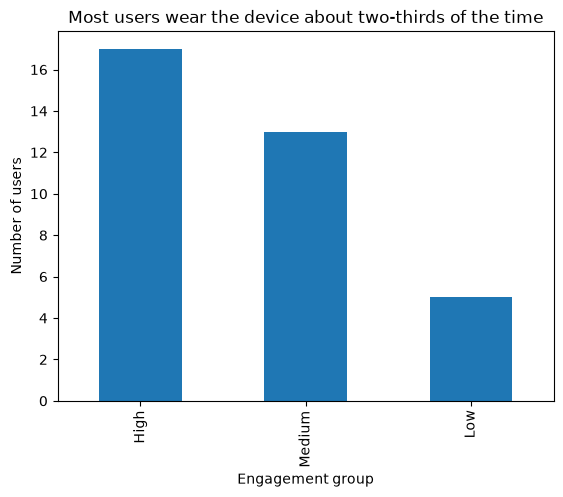

In [60]:
engagement["group"].value_counts().plot(kind="bar", title="Most users wear the device about two-thirds of the time")
plt.ylabel("Number of users")
plt.xlabel("Engagement group")
plt.savefig(path / "User_engagement.png", dpi=300, bbox_inches="tight")
plt.show()

#### Q1 Finding
Engagement is moderate and no user is fully engaged. Over a 62-day period,
the most engaged user recorded wear on about 79% of days, most users sit
near two-thirds, and 2 of 35 users recorded almost nothing (under 10 days).
Users were grouped as High (above 65% of days), Medium (45% to 65%) and
Low (under 45%). The cut-offs are a judgment call, not natural breaks in the data.

### Q2 What does everyday movement looklike

In [21]:
avg_activity_level = activity.loc[activity["worn"] == True,
                                  ["sedentaryminutes", "lightlyactiveminutes",
                                   "fairlyactiveminutes", "veryactiveminutes"]].mean().round()

print(avg_activity_level)

sedentaryminutes        949.0
lightlyactiveminutes    203.0
fairlyactiveminutes      15.0
veryactiveminutes        22.0
dtype: float64


In [22]:
worn_rows = activity[activity["worn"] == True].copy()

worn_rows["total_minutes"] = (worn_rows["sedentaryminutes"]
                              + worn_rows["lightlyactiveminutes"]
                              + worn_rows["fairlyactiveminutes"]
                              + worn_rows["veryactiveminutes"])

In [23]:
for cutoff in [600, 900, 1200, 1400]:
    share = (worn_rows["total_minutes"] >= cutoff).mean() * 100
    print(cutoff, "minutes:", round(share, 1), "% of worn days")

600 minutes: 97.2 % of worn days
900 minutes: 87.5 % of worn days
1200 minutes: 52.1 % of worn days
1400 minutes: 46.7 % of worn days


Wear-time check:
Among days with any recorded activity, 97% recorded at least 10 hours and 88% at least
15 hours.

In [24]:
worn_rows["group"] = worn_rows["id"].map(engagement["group"])

four_buckets = ["sedentaryminutes", "lightlyactiveminutes",
                "fairlyactiveminutes", "veryactiveminutes"]

print(worn_rows.groupby("group", observed=True)[four_buckets].mean().round(0))

        sedentaryminutes  lightlyactiveminutes  fairlyactiveminutes  \
group                                                                 
Low               1192.0                 108.0                 26.0   
Medium             991.0                 209.0                 13.0   
High               899.0                 210.0                 15.0   

        veryactiveminutes  
group                      
Low                  13.0  
Medium               17.0  
High                 25.0  


### What time of day are people most active

In [25]:
print(steps.head())

           id        activityhour  steptotal
0  1503960366 2016-03-12 00:00:00          0
1  1503960366 2016-03-12 01:00:00          0
2  1503960366 2016-03-12 02:00:00          0
3  1503960366 2016-03-12 03:00:00          0
4  1503960366 2016-03-12 04:00:00          0


In [26]:
# Getting average total steps per hour
# Pull the hour (0-23) out of the timestamp so I can average steps by hour of day

steps["hour"] = steps["activityhour"].dt.hour
print(steps.groupby("hour")["steptotal"].mean().round(0))

hour
0      43.0
1      22.0
2      14.0
3       7.0
4      11.0
5      35.0
6     148.0
7     283.0
8     396.0
9     431.0
10    454.0
11    455.0
12    534.0
13    496.0
14    506.0
15    398.0
16    471.0
17    500.0
18    550.0
19    555.0
20    378.0
21    284.0
22    204.0
23    112.0
Name: steptotal, dtype: float64


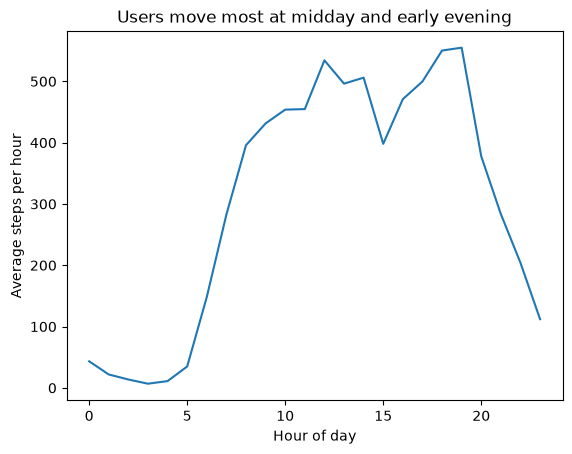

In [59]:
hourly_avg = steps.groupby("hour")["steptotal"].mean()

hourly_avg.plot(kind="line", title="Users move most at midday and early evening")
plt.xlabel("Hour of day")
plt.ylabel("Average steps per hour")
plt.savefig(path / "Avg_step_perhour.png", dpi=300, bbox_inches="tight")
plt.show()

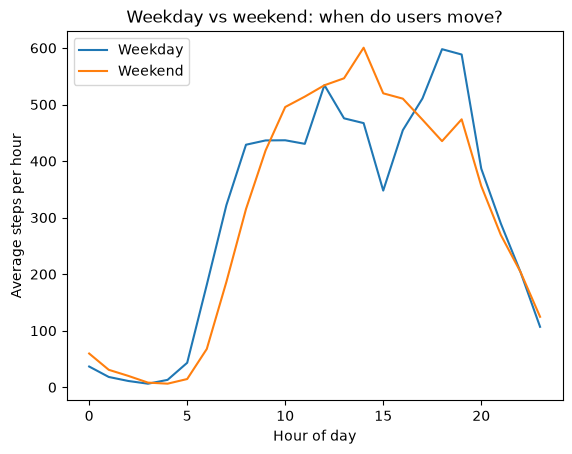

In [58]:
# Weekday vs weekend comparison
# Monday = 0 ... Sunday = 6, so 5 and 6 are the weekend

steps["is_weekend"] = steps["activityhour"].dt.dayofweek >= 5

weekend_steps = steps[steps['is_weekend'] == True]
weekday_steps = steps[steps['is_weekend'] == False]

weekday_steps.groupby('hour')['steptotal'].mean().plot(kind='line', label='Weekday')
weekend_steps.groupby('hour')['steptotal'].mean().plot(kind='line', label='Weekend')

plt.title('Weekday vs weekend: when do users move?')
plt.xlabel('Hour of day')
plt.ylabel('Average steps per hour')
plt.legend()
plt.savefig(path / "weekday_vs_weekend.png", dpi=300, bbox_inches="tight")
plt.show()

#### Q3 Finding: 
Activity follows a two-peak daily pattern: a midday peak (12 to 2 pm) and a higher
evening peak (6 to 7 pm), with a short dip around 3 pm and near-zero movement
from 1 to 4 am. Weekdays and weekends are combined

Weekdays show two activity peaks (midday and 6 to 7 pm) with a sharp dip around 3 pm.
Weekends show a single broad peak in the early afternoon, a morning start about an hour
later, and lower evening activity.

### Q4 How do users sleep, and how many track it?

In [31]:
# nunique counts distinct DAYS, not rows, so a nap on the same day doesn't count twice

nights_per_user = sleep.groupby("id")["sleepday"].nunique()
print("Users who logged sleep:", len(nights_per_user), "of", activity["id"].nunique())
print(nights_per_user.describe())

Users who logged sleep: 24 of 35
count    24.000000
mean     17.083333
std      11.378533
min       1.000000
25%       4.750000
50%      20.500000
75%      27.250000
max      31.000000
Name: sleepday, dtype: float64


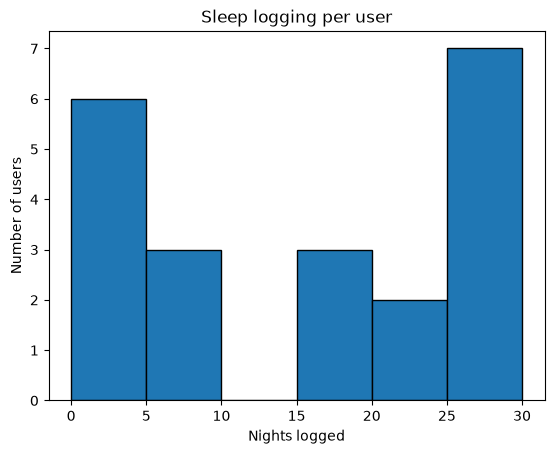

In [57]:
nights_per_user.plot(kind="hist", bins=range(0, 35, 5), edgecolor="black")
plt.xlabel("Nights logged")
plt.ylabel("Number of users")
plt.xticks(range(0,35,5))
plt.title("Sleep logging per user")
plt.savefig(path / "sleep_logging_per_user.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
# Keep only activity from the first sleep date onward, so steps and sleep cover the same weeks.
# Date is hardcoded from the sleep range checked above (2016-04-12)

same_window = activity[activity["activitydate"] >= "2016-04-12"]
print(same_window.groupby("id")["activitydate"].nunique().describe())

count    33.000000
mean     28.484848
std       5.657524
min       4.000000
25%      29.000000
50%      31.000000
75%      31.000000
max      31.000000
Name: activitydate, dtype: float64


In [52]:
avg_steps = same_window.groupby("id")["totalsteps"].mean

# No join needed: both are indexed by user id, so pandas lines them up automatically.
# Users with no sleep data (11) have no label and drop out silently, so this compares 24 users

groups = pd.cut(nights_per_user, bins=[0, 7, 21, 31], labels=["Low", "Mid", "High"])
print(avg_steps.groupby(groups).agg(["count", "mean", "median"]))

          count         mean       median
sleepday                                 
Low           8  6289.244903  5860.773656
Mid           4  4940.644969  4519.373272
High         12  8575.008333  8462.887097


Users who logged sleep on 22 or more nights (n=12) had a median of about 8,460 steps per day, compared with about 5,860 for users who logged 1-7 nights (n=8). The Mid group (n=4) had the lowest median (about 4,520), but with only four users it is too small to interpret. Overall, heavier sleep logging is associated with higher daily activity in this sample.

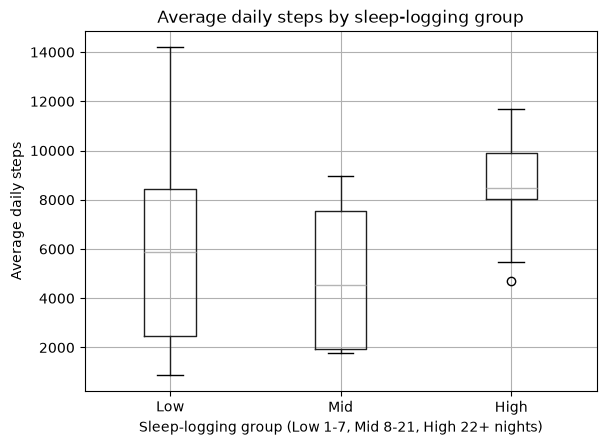

In [62]:
plot_data = avg_steps.to_frame().join(groups.rename("group"), how="inner")
plot_data.boxplot(column="totalsteps", by="group")
plt.title("Average daily steps by sleep-logging group")
plt.suptitle("")
plt.xlabel("Sleep-logging group (Low 1-7, Mid 8-21, High 22+ nights)")
plt.ylabel("Average daily steps")
plt.savefig(path / "sleep_by_activity.png", dpi=300, bbox_inches="tight")
plt.show()